In [24]:
%pip install -Uqqq langgraph langgraph-supervisor langchain langchain-openai langchain-tavily langchain-experimental

Note: you may need to restart the kernel to use updated packages.


In [25]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

# 도구 생성

In [26]:
from langchain_tavily import TavilySearch
from langchain_experimental.tools import PythonREPLTool

tavily_tool = TavilySearch(max_results=3)
python_repl_tool = PythonREPLTool()

In [27]:
# 에이전트 노드 실행기 : 각 에이전트 답변을 사람메세지ㅣ로 재가공하는 헬퍼 함수
from langchain_core.messages import HumanMessage

# 에이전트를 실행하고, 마지막 ai 응답을 HumanMessage로 반환하는 함수
def agent_node(state, agent, name):
    response = agent.invoke(state)
    # 마지막 응답은 지정된 name의 HumanMessage 형태로 반환
    return {'messages': [HumanMessage(content=response['messages'][-1].content, name=name)]}


# Supervisor Agent 구성
- 다음 작업자  (Researcher / Coder / FINISH) 결정

In [28]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.chat_models import init_chat_model
from pydantic import BaseModel      # 구조화 출력
from typing import Literal          # 값 제한

# gpt-5.6-luna는 chat completions에서 function tool 사용 시 reasoning_effort='none' 필요
llm = init_chat_model('gpt-5.6-luna', reasoning_effort='none')

members = ['Researcher', 'Coder']   # 하위 에이전트

# Supervisor 역할/지침(system) 프롬프트
system_prompt = """다음 작업자들 간의 대화를 관리하는 관리자로서 당신은 다음 작업자들을 관리합니다: {members}.

아래의 사용자 요청을 참고하여, 다음 작업을 수행할 작업자를 지정하세요.
각 작업자는 작업을 수행하고 그 결과와 상태를 보고할 것입니다.
모든 작업이 완료되면 FINISH로 응답하세요."""

options = members + ['FINISH']      # Supervisor의 선택지

# Supervisor 응답은 구조화된 형태
class RouteResponse(BaseModel):
    next: Literal['FINISH', 'Researcher', 'Coder']

prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    MessagesPlaceholder(variable_name='messages'),
    ('system', '''
    위 대화를 참고하여, 누가 다음으로 행동해야 하나요? 아니면 작업을 FINISH 해야 하나요?
다음 중 하나를 선택하세요: {options}
    '''),
]).partial(options=str(options), members=', '.join(members))

def supervisor_agent(state):
    supervisor_chain = prompt | llm.with_structured_output(RouteResponse)
    response = supervisor_chain.invoke(state)
    return {'next': response.next}


# Graph 조립

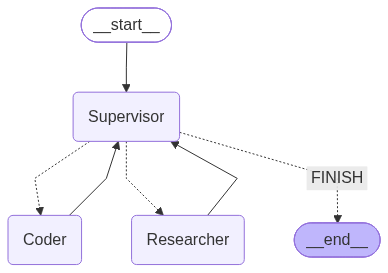

In [29]:
from typing import TypedDict, Annotated, List       # 상태 타입 정의
from langgraph.graph import StateGraph, START, END  # Langgraph 구성요소
from langgraph.graph.message import add_messages    # Messages 누적 처리 유틸
from langchain_core.messages import BaseMessage     # Messages 타입 힌트 정의
from langchain.agents import create_agent           # Tool 사용하는 에이전트
import functools    # partial 사용 (값을 미리 고정)

# 그래프에서 사용할 상태 스키마 커스터마이징
class AgentState(TypedDict):
    messages : Annotated[List[BaseMessage], add_messages]   # messages는 add_messages의 규칙으로 누적
    next: str   # Supervisor가 결정한 다음 노드

research_agent = create_agent(llm, tools=[tavily_tool])
# functools.partial():  기존함수의 일부 인자를 미리 채운 함수를 반환
research_node = functools.partial(agent_node, agent=research_agent, name='Researcher')

code_agent = create_agent(llm, tools=[python_repl_tool])
code_node = functools.partial(agent_node, agent=code_agent, name='Coder')

workflow = StateGraph(AgentState)

# 노드
workflow.add_node('Supervisor', supervisor_agent)
workflow.add_node('Researcher', research_node)
workflow.add_node('Coder', code_node)

# 엣지
workflow.add_edge(START, 'Supervisor')
workflow.add_edge('Researcher', 'Supervisor')
workflow.add_edge('Coder', 'Supervisor')

conditional_map = {member: member for member in members}
conditional_map['FINISH'] = END

workflow.add_conditional_edges('Supervisor', lambda state: state['next'], conditional_map)

graph = workflow.compile()
graph

In [30]:
for chunk in graph.stream({
    'messages':[
        ('human', '2026년 9월 4일 오늘 기준 삼성전자 주가를 mapplotlib로 시각화 해줘')
    ]
}):
    print(chunk)

{'Supervisor': {'next': 'Researcher'}}
{'Researcher': {'messages': [HumanMessage(content='2026년 **9월 4일은 현재 기준으로 아직 장중/장 마감 데이터가 확인되지 않으므로**, 확인 가능한 최신 거래일인 **9월 3일 종가 기준**으로 시각화할 수 있습니다.\n\n- 삼성전자 종가: **250,000원**\n- 9월 3일 시가: 254,000원\n- 고가: 255,000원\n- 저가: 243,000원\n- 등락률: **-0.20%**\n- 거래량: 약 **1,372만 주**\n\n아래 코드는 최근 거래일 데이터를 직접 입력해 `matplotlib`로 캔들 차트와 거래량을 시각화합니다.\n\n```python\nimport matplotlib.pyplot as plt\nimport matplotlib.dates as mdates\nfrom matplotlib.patches import Rectangle\nfrom datetime import datetime\n\n# 삼성전자(005930) 최근 거래일 데이터\ndata = [\n    # 날짜, 시가, 고가, 저가, 종가, 거래량\n    ("2026-08-28", 262500, 266000, 256000, 257000, 14.70),\n    ("2026-08-31", 249000, 260000, 246000, 260000, 17.01),\n    ("2026-09-01", 256500, 262500, 254000, 261000, 12.77),\n    ("2026-09-02", 252000, 255500, 249500, 250500, 15.16),\n    ("2026-09-03", 254000, 255000, 243000, 250000, 13.72),\n]\n\ndates = [datetime.strptime(row[0], "%Y-%m-%d") for row in data]\nopens = [row[1] for row in data

Python REPL can execute arbitrary code. Use with caution.


{'Coder': {'messages': [HumanMessage(content='아래 코드는 제공된 **2026년 9월 3일 기준 삼성전자 데이터**를 이용해 `matplotlib`으로 주가와 거래량을 시각화합니다.  \n단, 실제 2026년 9월 4일 종가는 장 마감 후 데이터로 갱신해야 합니다.\n\n```python\nimport matplotlib.pyplot as plt\nfrom matplotlib.patches import Rectangle\nfrom datetime import datetime\n\n# 삼성전자(005930) 데이터\ndata = [\n    ("2026-08-28", 262500, 266000, 256000, 257000, 14.70),\n    ("2026-08-31", 249000, 260000, 246000, 260000, 17.01),\n    ("2026-09-01", 256500, 262500, 254000, 261000, 12.77),\n    ("2026-09-02", 252000, 255500, 249500, 250500, 15.16),\n    ("2026-09-03", 254000, 255000, 243000, 250000, 13.72),\n]\n\ndates = [datetime.strptime(x[0], "%Y-%m-%d") for x in data]\nopens = [x[1] for x in data]\nhighs = [x[2] for x in data]\nlows = [x[3] for x in data]\ncloses = [x[4] for x in data]\nvolumes = [x[5] for x in data]\n\n# 한글 폰트 설정\nplt.rcParams["font.family"] = "Malgun Gothic"  # Windows\nplt.rcParams["axes.unicode_minus"] = False\n\nfig, (ax_price, ax_volume) = plt.subplots(\